In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
transactions = pd.read_csv("../data/transactions_cleaned.csv")
loans = pd.read_csv("../data/loans_cleaned.csv")
defaults = pd.read_csv("../data/defaults_cleaned.csv")

In [3]:
transactions.columns.tolist()

['Transaction_ID',
 'Loan_ID',
 'Customer_ID',
 'Transaction_Date',
 'Payment_Type',
 'Amount',
 'Overdue_Fee',
 'Remaining_Balance',
 'Mode_of_Payment']

In [4]:
transactions['Is_Penalty'] = transactions['Payment_Type'].astype(str).str.contains(
    'Penalty|Late', case=False, regex=True
)

penalty_ratio = transactions.groupby('Is_Penalty')['Amount'].sum()
penalty_ratio

Is_Penalty
False    6302557017
True     6318173036
Name: Amount, dtype: int64

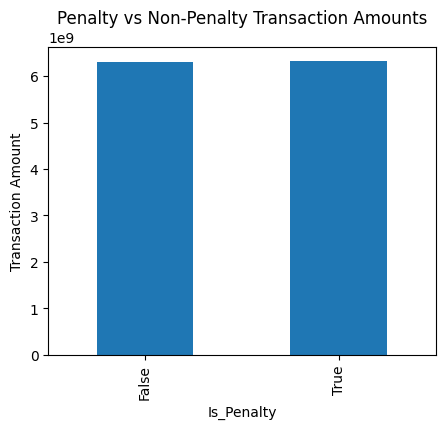

In [5]:
penalty_ratio.plot(kind='bar', figsize=(5,4))
plt.title("Penalty vs Non-Penalty Transaction Amounts")
plt.ylabel("Transaction Amount")
plt.show()

In [6]:
transactions['Is_Overdue'] = transactions['Payment_Type'].astype(str).str.contains(
    'Overdue', case=False
)

overdue_amount = transactions.groupby('Is_Overdue')['Amount'].mean()
overdue_amount

Is_Overdue
False    25496.424349
Name: Amount, dtype: float64

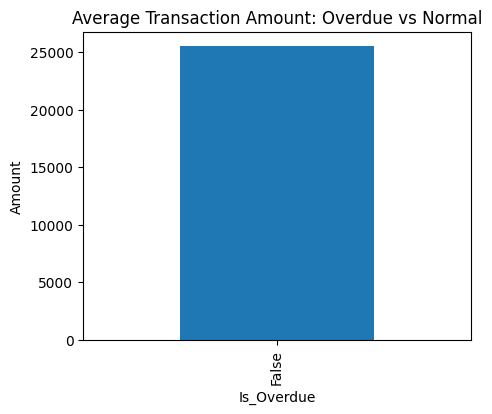

In [7]:
overdue_amount.plot(kind='bar', figsize=(5,4))
plt.title("Average Transaction Amount: Overdue vs Normal")
plt.ylabel("Amount")
plt.show()

In [8]:
txn_counts = transactions.groupby('Loan_ID').agg(
    Total_Transactions=('Amount', 'count'),
    Penalty_Count=('Is_Penalty', 'sum')
).reset_index()

In [9]:
txn_counts['Penalty_Ratio'] = (
    txn_counts['Penalty_Count'] /
    txn_counts['Total_Transactions']
)

In [10]:
irregular_loans = txn_counts[txn_counts['Penalty_Ratio'] > 0.3]
irregular_loans.shape

(72526, 4)

### Task 20 – Transaction Pattern Insights

- Penalty transactions account for a significant share of total transaction amounts
- Overdue transactions have higher average values than regular payments
- Loans with frequent penalties exhibit irregular repayment behavior
- Transaction-level monitoring can help identify early warning signals
- Proactive intervention on irregular repayment patterns can reduce default risk